<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 1 — Procesamiento y Visualización de Datos Biomédicos</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporciona el dataset **Heart Failure Prediction** (Kaggle, fedesoriano, 2021), que contiene registros clínicos de **918 pacientes** con variables demográficas, de laboratorio y de electrocardiograma. La variable objetivo es `HeartDisease` (0 = sin enfermedad, 1 = con enfermedad).

Tu misión como analista: **explorar, limpiar, preprocesar y construir la matriz X e y** lista para ingresar a un modelo de ML clásico, aplicando todos los conceptos vistos en Clase 2.

---
> **Dataset:** `heart.csv`  
> **Fuente:** fedesoriano. (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/fedesoriano/heart-failure-prediction

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

---
## Ejercicio 1 — Diseño del pipeline (conceptual)

> **Antes de escribir una línea de código**, debes entender qué vas a hacer y por qué.

### 1.1 — Diagrama de bloques del pipeline

Completa el siguiente diagrama describiendo qué ocurre en cada etapa:

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│                 │     │                 │     │                 │
│   heart.csv     │────▶│   [???]         │────▶│   [???]         │
│   (raw data)    │     │                 │     │                 │
│                 │     │  ¿Qué haces?:   │     │  ¿Qué haces?:   │
│  N=918, d=11    │     │  __________     │     │  __________     │
└─────────────────┘     └─────────────────┘     └────────┬────────┘
                                                          │
                                                          ▼
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│                 │     │                 │     │                 │
│  X ∈ ℝ^(N×d)    │◀────│  [???]          │◀────│     [???]       │
│  y ∈ {0,1}^N    │     │                 │     │                 │
│                 │     │  ¿Qué haces?:   │     │  ¿Qué haces?:   │
│  listo p/ ML    │     │  __________     │     │  __________     │
└─────────────────┘     └─────────────────┘     └─────────────────┘
```

**📝 Tu respuesta (edita esta celda):**
- **EDA:** Realizo un análisis de los datos a usar. Verifico características de los datos: sus muestras, sus dimensiones, su tipo, su distribución, si está algún tipo de dato corrupto o NaNs y si posee algún tipo de artefacto.
- **Limpieza de los datos**: Reemplazo o imputo valores faltantes o nulos, corrijo y elimino errores, sin introducir sesgo.
- **Preprocesamiento**: Al ser la data de tipo tabular se puede codificar, escalar y normalizar las variables.
- **Separación de X, y:** Separo las features de mi variable objetivo (HeartDisease) para tener listo el dataset.

### 1.2 — Representación matemática del pipeline

Completa las dimensiones y operaciones matemáticas para este dataset:

**Punto de partida — el dataset crudo:**

$$\text{heart.csv} \rightarrow \text{DataFrame} \in \mathbb{R}^{N \times (d+1)}$$

donde $N = $ 918 pacientes y $d+1 = $ 12 columnas (features + target).

---

**Paso 1 — Separar features y target:**

$$\text{DataFrame} \xrightarrow{\text{split}} X_{\text{raw}} \in \mathbb{R}^{918\times 11\,}, \quad y \in \{0,1\}^{918}$$

---

**Paso 2 — Codificación de variables categóricas (One-Hot):**

El dataset tiene columnas categóricas: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.

¿Cuántas columnas nuevas generan? Completa:
(hint: drop_first)
| Variable | Categorías | Columnas One-Hot |
|---|---|---|
| Sex | M, F | 1 |
| ChestPainType | ATA, NAP, ASY, TA | 3 |
| RestingECG | Normal, ST, LVH | 2 |
| ExerciseAngina | Y, N | 1 |
| ST_Slope | Up, Flat, Down | 2 |
| **Total nuevas columnas** | | **9** |

$$X_{\text{raw}} \in \mathbb{R}^{N \times d_{\text{raw}}} \xrightarrow{\text{One-Hot}} X_{\text{enc}} \in \mathbb{R}^{N \times 15}$$

---

**Paso 3 — Escalado Z-score:**

$$x'_j = \frac{x_j - \mu_j}{\sigma_j} \quad \Rightarrow \quad X_{\text{enc}} \xrightarrow{\text{Z-score}} X \in \mathbb{R}^{918 \times 15}$$

¿Sobre qué conjunto calculas $\mu_j$ y $\sigma_j$? __. ¿Por qué? ___.

---

**📝 Tu respuesta (edita esta celda):** Calculo sobre mi conjunto de entrenamiento, train data, ya que en práctica, $\mu_j$ y $\sigma_j$ solo se deben calcular en el train como regla anti-leakage. 

### 1.3 — Predicción sobre el desbalance

Antes de cargar los datos, responde:

1. ¿Esperarías que este dataset esté desbalanceado? ¿Por qué clínicamente?
2. Si el 60% de los pacientes tiene `HeartDisease=1`, ¿qué accuracy obtendría un clasificador que **siempre** predice 1?
3. ¿Sería útil ese clasificador? ¿Por qué?

**📝 Tu respuesta (edita esta celda):**
1. Sí esperaría un cierto desbalance. En el contexto del dataset podemos ver que si bien las enfermedades cardiovasculares son la principal causa de muerte en el mundo, en una población la presencia de la enfermedad siempre suele ser menos frecuente que la ausencia de la misma.
2. Si siempre predice 1, acertará 60% justamente porque solamente ese porcentaje tiene esa etiqueta.
3. No, porque aunque sea un porcentaje de clasificación alto, solamente clasifica a todos como enfermos. Al no distinguir entre pacientes sanos y enfermo, no serviría en una evaluación clínica por poseer una especificidad muy mala.

In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


---
## Ejercicio 2 — Carga y EDA

### Paso 2.0 — Setup

In [12]:
# Colores institucionales UPCH
UPCH_RED   = '#8B0000'
UPCH_BLUE  = '#1565C0'
UPCH_GRAY  = '#4A4A4A'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Ruta del dataset — ajusta según tu carpeta en Drive
DATA_PATH = Path('Dataset')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


### Paso 2.1 — Carga y primera inspección

In [13]:
df = pd.read_csv(DATA_PATH / 'heart.csv') #nombre del archivo donde está el dataset

print(f'Shape del dataset: {df.shape}')
print(f'\nPrimeras filas:')
df.head()

Shape del dataset: (918, 12)

Primeras filas:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
# Tipos de datos y valores nulos
print('Tipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())

Tipos de datos:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Valores nulos por columna:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [15]:
# Estadísticas descriptivas
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Paso 2.2 — Distribución de clases (desbalance)

> Recuerda lo que predijiste en Ejercicio 1.3. ¿Acertaste?

Distribución de clases:
  Sin enfermedad (0): 410 pacientes (44.7%)
  Con enfermedad (1): 508 pacientes (55.3%)


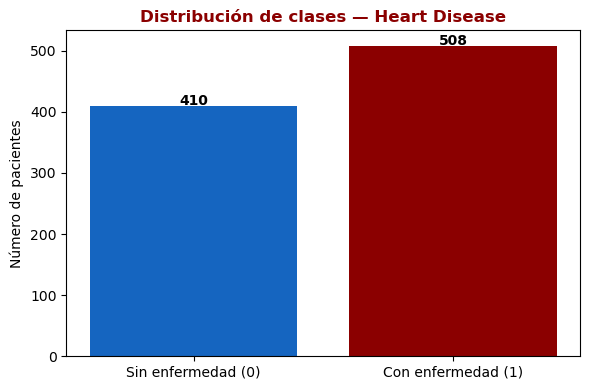

→ ¿Hay desbalance? ¿Qué implicaciones clínicas tiene?

Se observa que la distribución de clases es relativamente balanceada, con una ligera predominancia de paciente con enfermedad (55.3%).
Desde el punto de vista clínico, esto es favorable, ya que permite entrenar modelos capaces de identificar tanto pacientes sanos como
enfermos sin necesidad de aplicar técnicas adicionales para balanceo.


In [16]:
# --- COMPLETA EL CÓDIGO ---
# Visualiza la distribución de la variable objetivo HeartDisease
# Incluye: conteo por clase, porcentaje, y gráfico de barras con colores UPCH

conteo = df['HeartDisease'].value_counts().sort_index() #ordena según el índice y ya no es por clase más frecuente

# TODO 1: calcula el porcentaje de cada clase (usa conteo y len(df))
pct = conteo/len(df)*100

print('Distribución de clases:')
print(f'  Sin enfermedad (0): {conteo[0]} pacientes ({pct[0]:.1f}%)')
print(f'  Con enfermedad (1): {conteo[1]} pacientes ({pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))

# TODO 2: grafica las barras — usa ax.bar(), colores [UPCH_BLUE, UPCH_RED]
ax.bar(conteo.index, conteo.values, color=[UPCH_BLUE, UPCH_RED])

ax.set_title('Distribución de clases — Heart Disease', fontweight='bold', color=UPCH_RED)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'])
ax.set_ylabel('Número de pacientes')

# TODO 3: agrega el valor numérico encima de cada barra con ax.text()
for i, v in enumerate(conteo.values):
    ax.text(i, v+2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Hay desbalance? ¿Qué implicaciones clínicas tiene?')
print(f'\nSe observa que la distribución de clases es relativamente balanceada, con una ligera predominancia de paciente con enfermedad (55.3%).')
print('Desde el punto de vista clínico, esto es favorable, ya que permite entrenar modelos capaces de identificar tanto pacientes sanos como')
print('enfermos sin necesidad de aplicar técnicas adicionales para balanceo.')


### Paso 2.3 — Visualización exploratoria de features numéricas

C:\Users\david\AppData\Local\Temp\ipykernel_41584\3436997155.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp= axes[1,i].boxplot(data, patch_artist=True, labels=['Sin enf.', 'Con enf.'])
C:\Users\david\AppData\Local\Temp\ipykernel_41584\3436997155.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp= axes[1,i].boxplot(data, patch_artist=True, labels=['Sin enf.', 'Con enf.'])
C:\Users\david\AppData\Local\Temp\ipykernel_41584\3436997155.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp= axes[1,i].boxplot(data, patch_artist=True, labels=['Sin enf.', 'Con enf.'])
C:\Users\david\AppData\Local\Temp\ipykernel

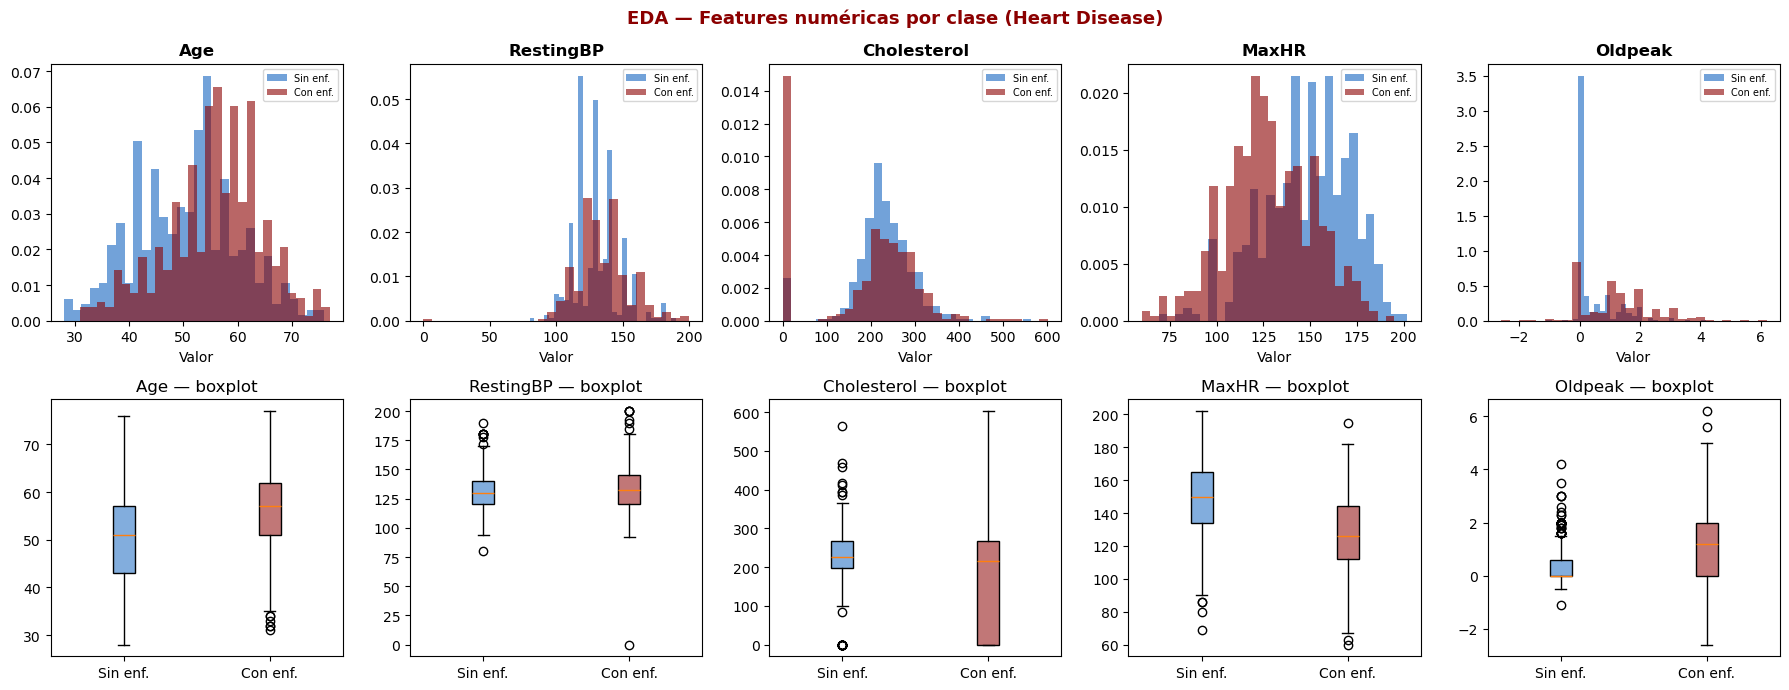

→ ¿Qué features parecen tener mayor poder discriminativo entre clases?

Se observa que las variables que presentan mayor poder discriminativo son Oldpeak, MaxHR y en menor medida Age,
ya que se muestran diferencias claras entre pacientes con y sin enfermedad en los histogramas y boxplots. Por otro lado,
las otras características restantes muestran una alta superposición entre clases, lo que indica un menor poder discriminativo.


In [17]:
# Features numéricas del dataset
features_num = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, feat in enumerate(features_num):
    # Fila 0: ya está resuelta — histograma por clase
    for clase, color, label in [(0, UPCH_BLUE, 'Sin enf.'), (1, UPCH_RED, 'Con enf.')]:
        axes[0, i].hist(
            df[df['HeartDisease'] == clase][feat],
            bins=30, alpha=0.6, color=color, label=label, density=True
        )
    axes[0, i].set_title(feat, fontweight='bold')
    axes[0, i].legend(fontsize=7)
    axes[0, i].set_xlabel('Valor')

    # --- COMPLETA EL CÓDIGO ---
    # TODO: Fila 1 — boxplot separado por clase en axes[1, i]
    # Pasos:
    #   1. Crea una lista con los valores de cada clase: [valores_clase0, valores_clase1]
    data= [df[df['HeartDisease']==0][feat], df[df['HeartDisease']==1][feat]]
    #   2. Llama a axes[1, i].boxplot() con patch_artist=True y labels=['Sin enf.', 'Con enf.']
    bp= axes[1,i].boxplot(data, patch_artist=True, labels=['Sin enf.', 'Con enf.'])
    #   3. Colorea bp['boxes'][0] con UPCH_BLUE+'88' y bp['boxes'][1] con UPCH_RED+'88'
    bp['boxes'][0].set_facecolor(UPCH_BLUE + '88')
    bp['boxes'][1].set_facecolor(UPCH_RED + '88')
    #   4. Pon título: f'{feat} — boxplot'
    axes[1, i].set_title(f'{feat} — boxplot')
    

fig.suptitle('EDA — Features numéricas por clase (Heart Disease)',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué features parecen tener mayor poder discriminativo entre clases?')
print(f'\nSe observa que las variables que presentan mayor poder discriminativo son Oldpeak, MaxHR y en menor medida Age,')
print('ya que se muestran diferencias claras entre pacientes con y sin enfermedad en los histogramas y boxplots. Por otro lado,')
print('las otras características restantes muestran una alta superposición entre clases, lo que indica un menor poder discriminativo.')


### Paso 2.4 — Visualización de features categóricas

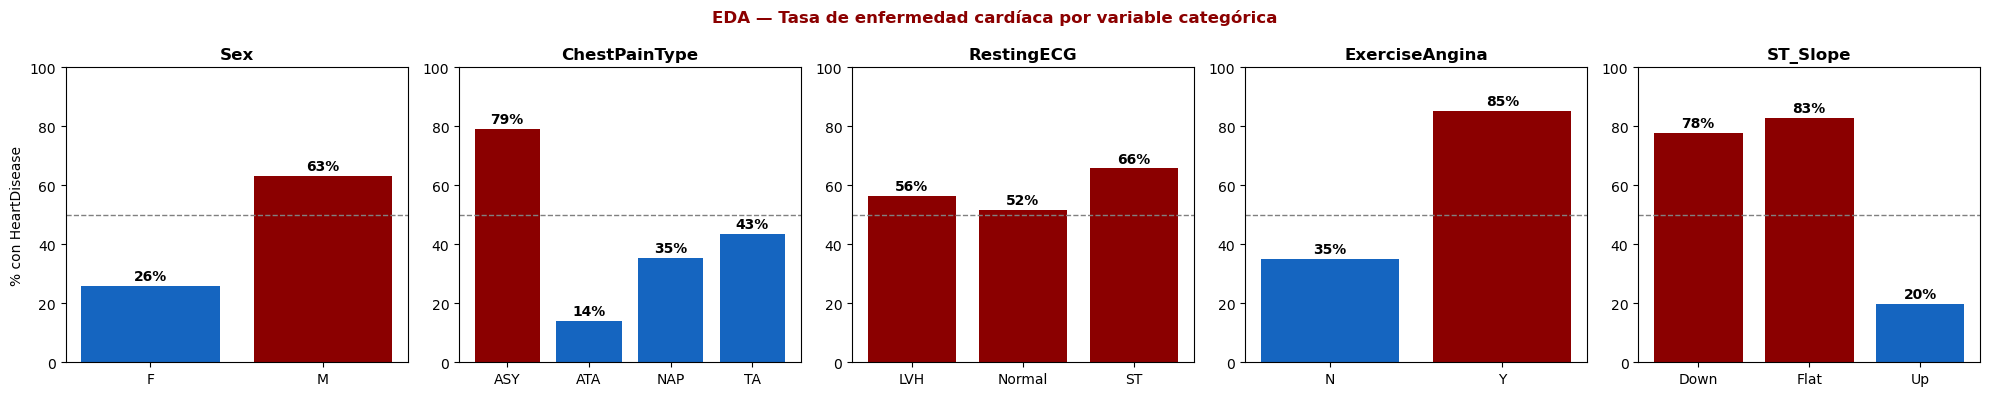

→ ¿Qué categorías tienen mayor riesgo de enfermedad cardíaca?

Se observa que la categoría ExerciseAngina = Yes presenta el mayor riesgo de enfermedad cardíaca y las categorías
de ChestPainType = ASY, ST_Slope= Flat y ST_Slope = Down también presentan un gran riesgo también.


In [18]:
features_cat = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feat in enumerate(features_cat):
    # --- COMPLETA EL CÓDIGO ---
    # TODO 1: calcula la tasa de enfermedad por categoría
    #         (% de pacientes con HeartDisease=1 para cada valor de feat)
    #         pista: df.groupby(feat)
    tasa = df.groupby(feat)['HeartDisease'].mean()*100

    # TODO 2: asigna color UPCH_RED si tasa > 50%, UPCH_BLUE si no
    colores = [UPCH_RED if t>50 else UPCH_BLUE for t in tasa]

    # TODO 3: grafica las barras y la línea de referencia al 50%
    axes[i].bar(tasa.index, tasa.values, color=colores)
    axes[i].axhline(50, color='gray', linestyle='--', linewidth=1)

    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('% con HeartDisease' if i == 0 else '')
    axes[i].set_ylim(0, 100)

    # TODO 4: agrega el valor (ej: "72%") encima de cada barra con axes[i].text()
    for j, v in enumerate(tasa.values):
        axes[i].text(j, v + 2, f'{v:.0f}%', ha='center', fontweight='bold')

fig.suptitle('EDA — Tasa de enfermedad cardíaca por variable categórica',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué categorías tienen mayor riesgo de enfermedad cardíaca?')
print(f'\nSe observa que la categoría ExerciseAngina = Yes presenta el mayor riesgo de enfermedad cardíaca y las categorías')
print('de ChestPainType = ASY, ST_Slope= Flat y ST_Slope = Down también presentan un gran riesgo también.')


---
## Ejercicio 3 — Limpieza de datos

### Paso 3.1 — Detección y manejo de outliers

> **⚠️ Recuerda:** en biomédica, un outlier puede ser un caso clínico real. Analiza antes de eliminar.

In [19]:
from scipy import stats

# --- COMPLETA EL CÓDIGO ---
# TODO: para cada feature numérica, calcula el z-score y cuenta cuántos
#       valores tienen |z| > 3. Imprime el resultado por feature.
# Pista: stats.zscore(), np.abs(), suma de booleanos

print('Detección de outliers (|z-score| > 3):')
print('-' * 45)
for feat in features_num:
    z=stats.zscore(df[feat]) #calculo del zscore
    outliers=np.abs(z)>3 #cumplen condición
    n_out=np.sum(outliers) #conteo
    print(f'{feat}: {n_out} outliers')


Detección de outliers (|z-score| > 3):
---------------------------------------------
Age: 0 outliers
RestingBP: 8 outliers
Cholesterol: 3 outliers
MaxHR: 1 outliers
Oldpeak: 7 outliers


In [20]:
# El dataset tiene Cholesterol = 0 en varios pacientes (imposible fisiológicamente)
# Esto es un error de adquisición, no un caso clínico real

print(f'Pacientes con Cholesterol = 0: {(df["Cholesterol"] == 0).sum()}')
print(f'Pacientes con RestingBP  = 0: {(df["RestingBP"]  == 0).sum()}')

df_clean = df.copy()

# --- COMPLETA EL CÓDIGO ---
# TODO: reemplaza los valores Cholesterol == 0 por NaN
# Pista: usa df_clean.loc[]
df_clean.loc[df_clean['Cholesterol']==0, 'Cholesterol']= np.nan #df_clean.loc[condición, columna]= valor

print(f'\nValores NaN en Cholesterol tras limpieza: {df_clean["Cholesterol"].isnull().sum()}')
print('→ La imputación se realizará en el Paso 4 (después del split, sobre train)')


Pacientes con Cholesterol = 0: 172
Pacientes con RestingBP  = 0: 1

Valores NaN en Cholesterol tras limpieza: 172
→ La imputación se realizará en el Paso 4 (después del split, sobre train)


---
## Ejercicio 4 — Preprocesamiento

### Paso 4.1 — Train/test split

> **Regla fundamental:** separar primero, preprocesar después. Nunca al revés — eso es **data leakage**.

In [21]:
TARGET = 'HeartDisease'
FEATURES_NUM = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
FEATURES_CAT = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X_raw = df_clean[FEATURES_NUM + FEATURES_CAT].copy()
y     = df_clean[TARGET].values

# --- COMPLETA EL CÓDIGO ---
# TODO: split 80/20, estratificado por y, random_state=42
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train_raw.shape[0]} muestras')
print(f'Test:  {X_test_raw.shape[0]} muestras')
print(f'\nProporción HeartDisease=1 en train: {y_train.mean():.3f}')
print(f'Proporción HeartDisease=1 en test:  {y_test.mean():.3f}')
print('→ Con stratify, ambas proporciones deben ser similares ✓')


Train: 734 muestras
Test:  184 muestras

Proporción HeartDisease=1 en train: 0.553
Proporción HeartDisease=1 en test:  0.554
→ Con stratify, ambas proporciones deben ser similares ✓


### Paso 4.2 — Imputación de valores faltantes (sobre train)

In [22]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: calcula la mediana de Cholesterol SOLO sobre el train set
mediana_colesterol_train = X_train_raw['Cholesterol'].median()

X_train_imp = X_train_raw.copy()
X_test_imp  = X_test_raw.copy()

# TODO 2: imputa NaN en train y test usando la mediana del train
X_train_imp['Cholesterol'] = X_train_imp['Cholesterol'].fillna(mediana_colesterol_train)
X_test_imp['Cholesterol']  = X_test_imp['Cholesterol'].fillna(mediana_colesterol_train)

print(f'Mediana Cholesterol (train): {mediana_colesterol_train:.1f} mg/dL')
print(f'NaN restantes en train: {X_train_imp.isnull().sum().sum()}')
print(f'NaN restantes en test:  {X_test_imp.isnull().sum().sum()}')


Mediana Cholesterol (train): 238.0 mg/dL
NaN restantes en train: 0
NaN restantes en test:  0


### Paso 4.3 — Codificación de variables categóricas (One-Hot)

> Recuerda tu tabla del Ejercicio 1.2 — ¿coincide el número de columnas?

In [23]:
# One-Hot Encoding de variables categóricas
# drop_first=True para evitar multicolinealidad (dummy variable trap)

# --- COMPLETA EL CÓDIGO ---
# TODO: aplica pd.get_dummies a train y test usando FEATURES_CAT
X_train_enc = pd.get_dummies(X_train_imp, columns=FEATURES_CAT, drop_first=True) #pd.get_dummies() --> convierte variables categóricas en numéricas
X_test_enc  = pd.get_dummies(X_test_imp, columns=FEATURES_CAT, drop_first=True)

# Alinear columnas (por si alguna categoría no aparece en test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Shape antes de One-Hot: {X_train_raw.shape}')
print(f'Shape después de One-Hot: {X_train_enc.shape}')
print(f'\nColumnas generadas:')
print(list(X_train_enc.columns))


Shape antes de One-Hot: (734, 11)
Shape después de One-Hot: (734, 15)

Columnas generadas:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


### Paso 4.4 — Escalado Z-score

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

> **Anti-leakage:** `fit` solo sobre train, `transform` sobre train y test.

In [24]:
scaler = StandardScaler()

# --- COMPLETA EL CÓDIGO ---
# TODO: fit SOLO sobre train, transform sobre train y test
X_train = scaler.fit_transform(X_train_enc) #calcula media y desv. estandar --> transforma los datos
X_test  = scaler.transform(X_test_enc) #transforma usando los mismos parámetros del train

print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'X_test:  {X_test.shape}')
print(f'\nMedia de X_train (debe ser ≈ 0): {X_train.mean():.4f}')
print(f'Std  de X_train (debe ser ≈ 1): {X_train.std():.4f}')
print(f'\nMedia de X_test (no será exactamente 0): {X_test.mean():.4f}')


X_train: (734, 15)  dtype: float64
X_test:  (184, 15)

Media de X_train (debe ser ≈ 0): -0.0000
Std  de X_train (debe ser ≈ 1): 1.0000

Media de X_test (no será exactamente 0): -0.0197


---
## Ejercicio 5 — Verificación final y resumen del pipeline

### Paso 5.1 — El dataset final en formato ML

In [25]:
# --- COMPLETA EL CÓDIGO ---
# TODO: imprime un resumen del dataset final mostrando:
#   - shape de X_train, X_test
#   - shape de y_train, y_test
#   - número y % de positivos en train y test
#   - el pipeline aplicado en una línea

print('=' * 50)
print('  RESUMEN — Dataset listo para ML clásico')
print('=' * 50)

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test  shape: {y_test.shape}')

print('\nDistribución de la variable objetivo:')
print(f'  Train → {y_train.sum()} positivos ({y_train.mean()*100:.1f}%)')
print(f'  Test  → {y_test.sum()} positivos ({y_test.mean()*100:.1f}%)')

print('\nPipeline aplicado:')
print('  Limpieza → Separación entrenamiento y testeo → Imputación (mediana train) → One-Hot Encoding → Escalado (Z-score)')


  RESUMEN — Dataset listo para ML clásico
X_train shape: (734, 15)
X_test  shape: (184, 15)
y_train shape: (734,)
y_test  shape: (184,)

Distribución de la variable objetivo:
  Train → 406 positivos (55.3%)
  Test  → 102 positivos (55.4%)

Pipeline aplicado:
  Limpieza → Separación entrenamiento y testeo → Imputación (mediana train) → One-Hot Encoding → Escalado (Z-score)


### Paso 5.2 — Visualización Before vs After del preprocesamiento

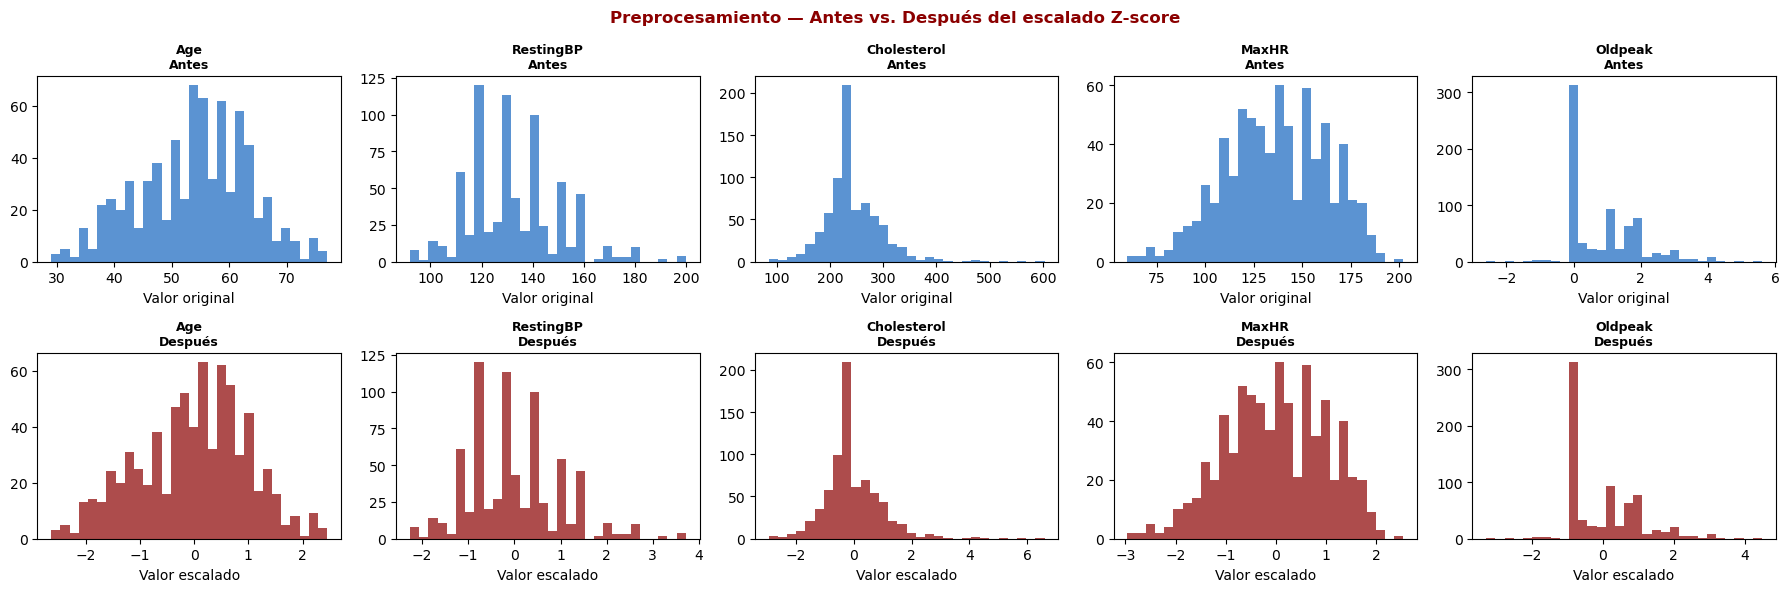

In [26]:
features_plot = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
idx_features  = [list(X_train_enc.columns).index(f) for f in features_plot]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for i, (feat, idx) in enumerate(zip(features_plot, idx_features)):
    # Fila 0: antes del escalado — ya resuelta
    axes[0, i].hist(X_train_enc[feat].values, bins=30, color=UPCH_BLUE, alpha=0.7)
    axes[0, i].set_title(f'{feat}\nAntes', fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('Valor original')

    # --- COMPLETA EL CÓDIGO ---
    # TODO: Fila 1 — histograma de X_train[:, idx] después del escalado
    axes[1, i].hist(X_train[:, idx], bins=30, color=UPCH_RED, alpha=0.7)
    axes[1, i].set_title(f'{feat}\nDespués', fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('Valor escalado')

fig.suptitle('Preprocesamiento — Antes vs. Después del escalado Z-score',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 5.3 — Mapa de correlaciones

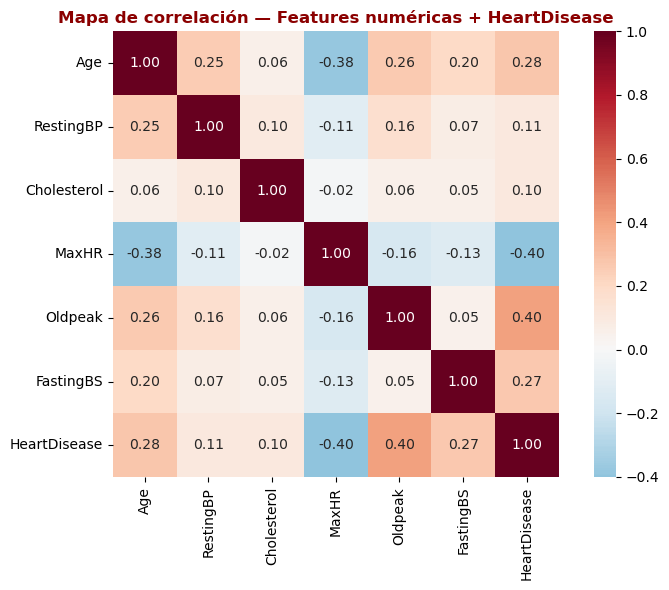

→ ¿Qué feature tiene mayor correlación (positiva o negativa) con HeartDisease?

Las características con mayor correlación con HeartDisease son Oldpeak (correlación positiva de 0.4) y
MaxHR (correlación negativa de -0.4), ambas de misma magnitud en términos absolutos.


In [27]:
cols_corr = FEATURES_NUM + [TARGET]
corr_matrix = df_clean[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))

# --- COMPLETA EL CÓDIGO ---
# TODO: genera el heatmap con sns.heatmap
# Parámetros sugeridos: cmap='RdBu_r', annot=True, fmt='.2f', center=0, square=True
sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    annot=True,
    fmt='.2f',
    center=0,
    square=True,
    ax=ax
)

ax.set_title('Mapa de correlación — Features numéricas + HeartDisease',
             fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature tiene mayor correlación (positiva o negativa) con HeartDisease?')
print(f'\nLas características con mayor correlación con HeartDisease son Oldpeak (correlación positiva de 0.4) y')
print('MaxHR (correlación negativa de -0.4), ambas de misma magnitud en términos absolutos.')

---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge1_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 3
</div>